# Detección de Comunidades en el Grafo de Epstein

El análisis de comunidades nos permite descubrir subestructuras ocultas dentro de una red compleja, agrupando individuos que están más estrechamente conectados entre sí que con el resto de la red. En el contexto de la red social de Jeffrey Epstein, esto es especialmente motivador, ya que nos ayuda a identificar "círculos internos", facciones o grupos de interés que interactuaban de forma frecuente.

En este cuaderno, aplicaremos y compararemos varios algoritmos de detección de comunidades para revelar cómo se fragmentaba o cohesionaba esta intrincada red social de contactos.

In [1]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from infomap import Infomap

# Cargamos el grafo
G = nx.read_gml('../data/processed/epstein_social_graph_cleaned.gml', label='id')

### 1. Método Louvain

**Concepto:** El algoritmo de Louvain es un método diseñado para extraer comunidades de grandes redes maximizando una métrica llamada **modularidad**. La modularidad evalúa la densidad de enlaces dentro de una misma comunidad frente a la densidad de enlaces esperada con el resto de los grupos.

**Contexto en el grafo:** Aplicar Louvain a la red de Epstein nos permite agrupar a las personas en clústeres principales, asumiendo que los individuos dentro de una misma comunidad compartían interacciones estrechas o un intermediario común muy fuerte.

**Explicación del código:** El siguiente bloque ejecuta la función `louvain_communities` de NetworkX. Luego, cuenta el número de comunidades detectadas e imprime la modularidad ($Q$) para evaluar matemáticamente la calidad de esta partición.

In [9]:
# 1. Eliminar self-loops si no tienen significado analítico especial
G.remove_edges_from(nx.selfloop_edges(G))

# 2. Comunidades Louvain
print("Ejecutando Louvain...")
comunidades_louvain = list(nx.community.louvain_communities(G, weight="weight", seed=42))

print(f"Louvain ha detectado {len(comunidades_louvain)} comunidades.")

# 3. Modularidad
modularidad = nx.community.modularity(G, comunidades_louvain, weight="weight")
print(f"La modularidad asociada a la partición de Louvain: {modularidad:.4f}")

Ejecutando Louvain...
Louvain ha detectado 72 comunidades.
La modularidad asociada a la partición de Louvain: 0.3319


A continuación, visualizamos de forma gráfica el resultado de la partición obtenida con Louvain.

**Explicación del código:** Creamos un mapa de colores (`cmap`) asignando un color distinto a cada comunidad identificada. Calculamos la posición de los nodos mediante un layout `spring_layout` y generamos el gráfico, destacando con etiquetas únicamente a los 15 individuos con mayor número de conexiones para facilitar la interpretación de quiénes operaban como "líderes" de los clústeres.

/var/folders/lw/hs5rfqwn01v9260m1xbp6dlh0000gn/T/ipykernel_17793/1327061223.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))


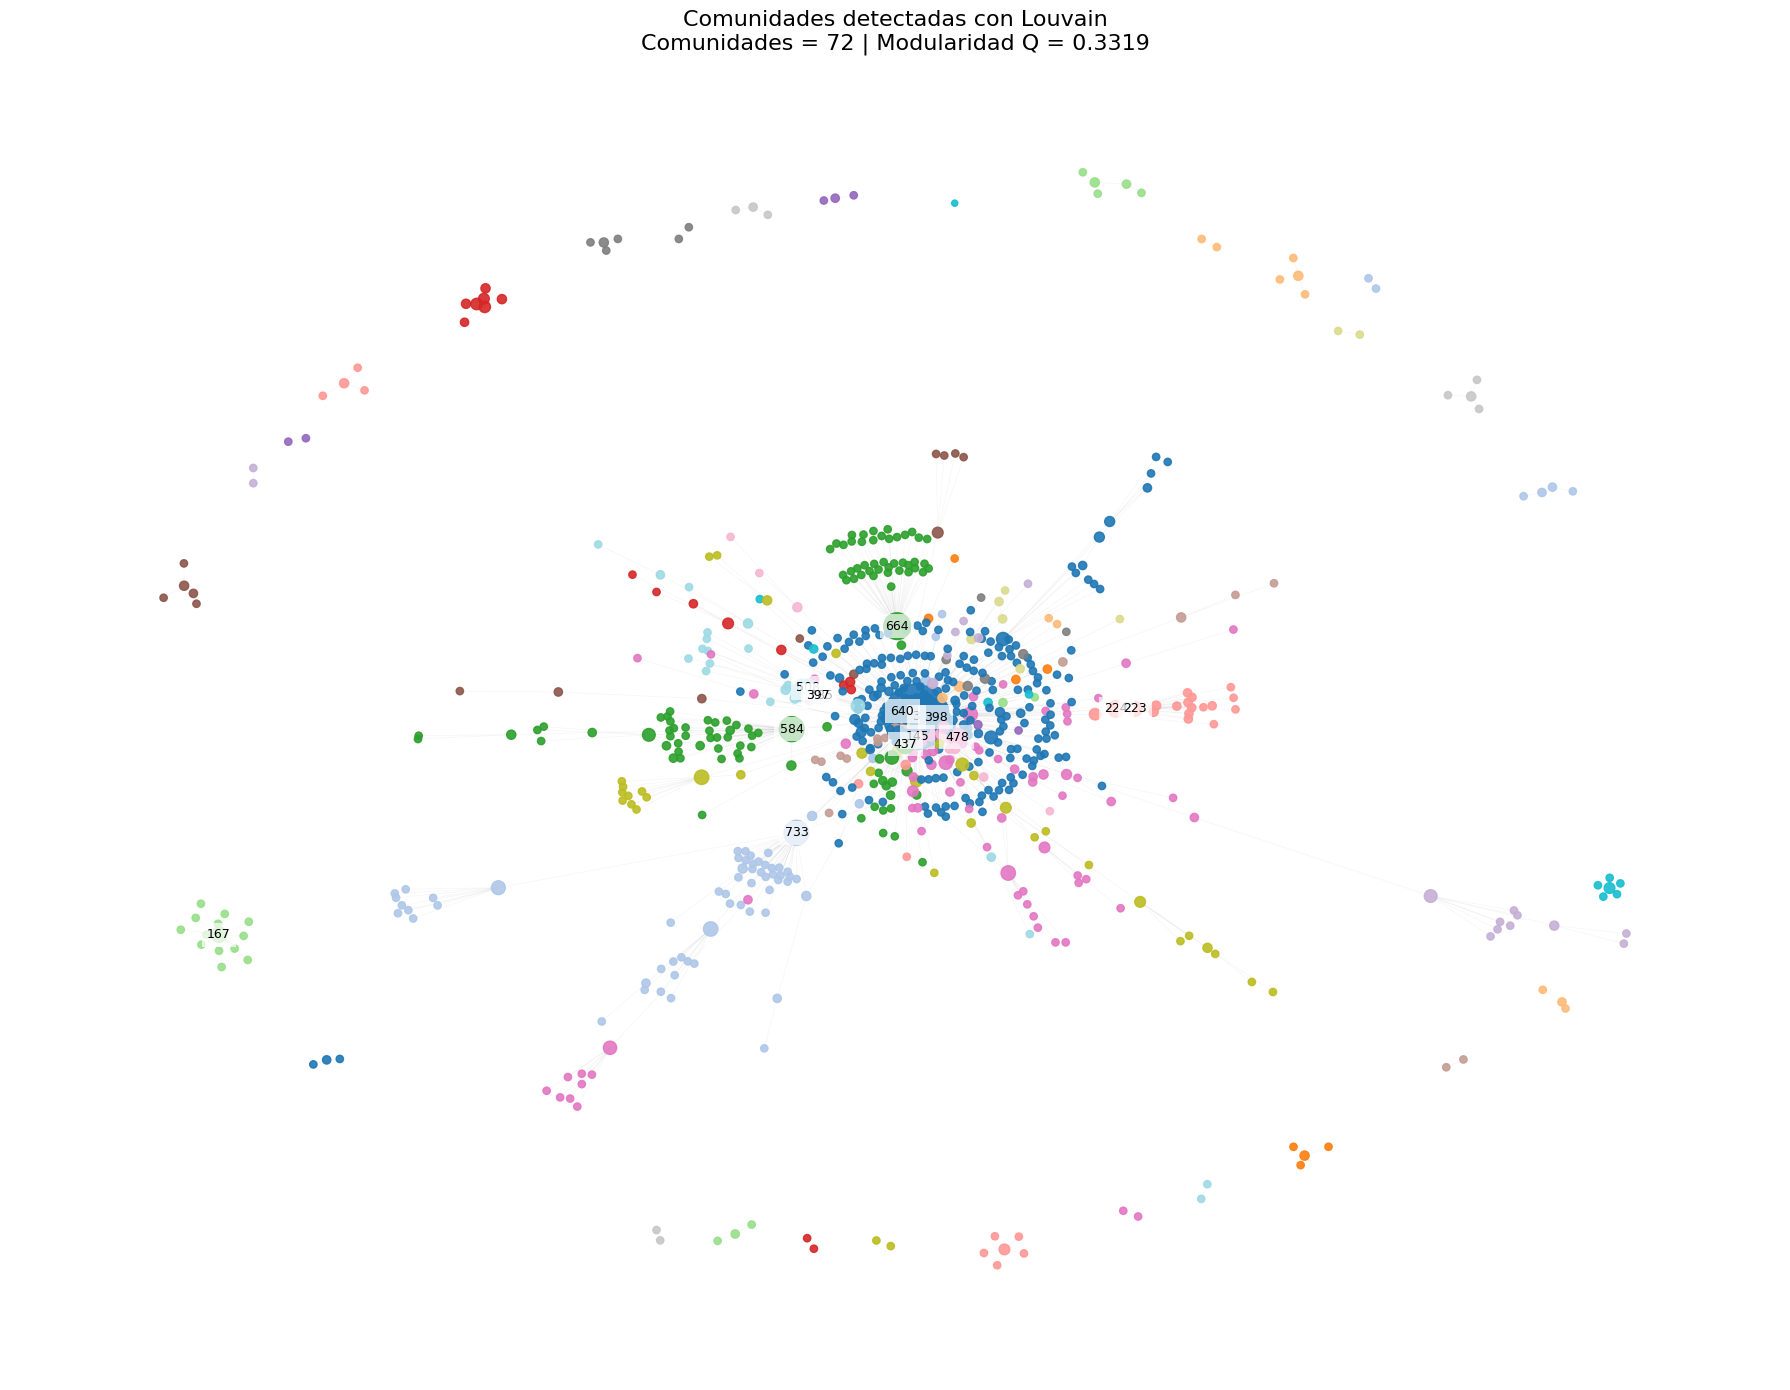

In [10]:
# 4. Mapa nodo -> comunidad
node_to_community = {}
for i, comunidad in enumerate(comunidades_louvain):
    for nodo in comunidad:
        node_to_community[nodo] = i

# 5. Colores por comunidad
num_comunidades = len(comunidades_louvain)
cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))
node_colors = [cmap(node_to_community[n]) for n in G.nodes()]

# 6. Layout más separado
pos = nx.spring_layout(G, k=1.2, iterations=300, seed=42)

# 7. Tamaño de nodo según grado
degrees = dict(G.degree())
node_sizes = [20 + 8 * degrees[n] for n in G.nodes()]

# 8. Dibujo
plt.figure(figsize=(18, 14))

nx.draw_networkx_edges(G,pos, alpha=0.08, width=0.5, edge_color="gray")

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# Dibujar solo etiquetas de los nodos más conectados
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:15]
labels = {n: str(n) for n in top_nodes}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color="black", bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

plt.title(f"Comunidades detectadas con Louvain\n" f"Comunidades = {len(comunidades_louvain)} | Modularidad Q = {modularidad:.4f}", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

### 2. Método Girvan-Newman (Top-Down)

**Concepto:** A diferencia de otros algoritmos aglomerativos, Girvan-Newman adopta un enfoque divisivo (de arriba hacia abajo). Funciona identificando y eliminando progresivamente las aristas con mayor centralidad de intermediación (*edge betweenness*), es decir, los "puentes" que conectan diferentes comunidades. Al eliminar estos puentes iterativamente, la red termina fragmentándose en grupos aislados más densos.

**Contexto en el grafo:** Aplicar este método a la red de Epstein es muy útil para descubrir las facciones fundamentales subyacentes. Al ir cortando las relaciones de los "intermediarios clave" o conectores principales, podemos ver cuáles son los grupos o camarillas más herméticas que quedarían aisladas sin estos canales de comunicación.

**Explicación del código:** El script comienza cargando el grafo y limpiándolo de *self-loops* (aristas que conectan a un individuo consigo mismo, las cuales no aportan valor analítico en este caso). Luego, inicializa el generador de particiones de Girvan-Newman. Dado que el algoritmo genera múltiples niveles de división (hasta que cada nodo es su propia comunidad), el código evalúa iterativamente solo las primeras 15 divisiones, guardando aquella que ofrezca la mejor **modularidad** ($Q$). Finalmente, se extraen las agrupaciones ganadoras, se asignan colores por comunidad, se ajusta el tamaño de los nodos según su cantidad de conexiones (grado) y se grafica la red resaltando a los 15 individuos más importantes.

In [15]:
# 1. Eliminar self-loops si no tienen valor analítico
G.remove_edges_from(nx.selfloop_edges(G))

print("Ejecutando Girvan-Newman (Top-Down)...")

# 2. Generador de particiones
generador_gn = nx.community.girvan_newman(G)

mejor_q = -1.0
mejor_particion_gn = None

# Evaluamos solo las primeras divisiones
for particion in itertools.islice(generador_gn, 15):
    q_actual = nx.community.modularity(G, particion, weight="weight")
    if q_actual > mejor_q:
        mejor_q = q_actual
        mejor_particion_gn = particion

print(f"Girvan-Newman ha detectado {len(mejor_particion_gn)} comunidades.")
print(f"Modularidad asociada a la partición de Girvan-Newman: {mejor_q:.4f}")

Ejecutando Girvan-Newman (Top-Down)...
Girvan-Newman ha detectado 41 comunidades.
Modularidad asociada a la partición de Girvan-Newman: 0.2209


Ahora, visualizamos el resultado de la partición obtenida con Girvan-Newman, destacando las comunidades detectadas y su calidad mediante la modularidad.

**Explicación del código:** Similar al bloque anterior, se asignan colores a cada comunidad y se calcula la posición de los nodos. El tamaño de cada nodo se ajusta en función de su grado (número de conexiones), lo que ayuda a identificar visualmente a los individuos más influyentes dentro de cada comunidad. Finalmente, se genera el gráfico con las aristas en gris claro para no distraer del enfoque en las comunidades y se añaden etiquetas solo a los 15 nodos más conectados para facilitar la interpretación.

/var/folders/lw/hs5rfqwn01v9260m1xbp6dlh0000gn/T/ipykernel_17793/4000814452.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))


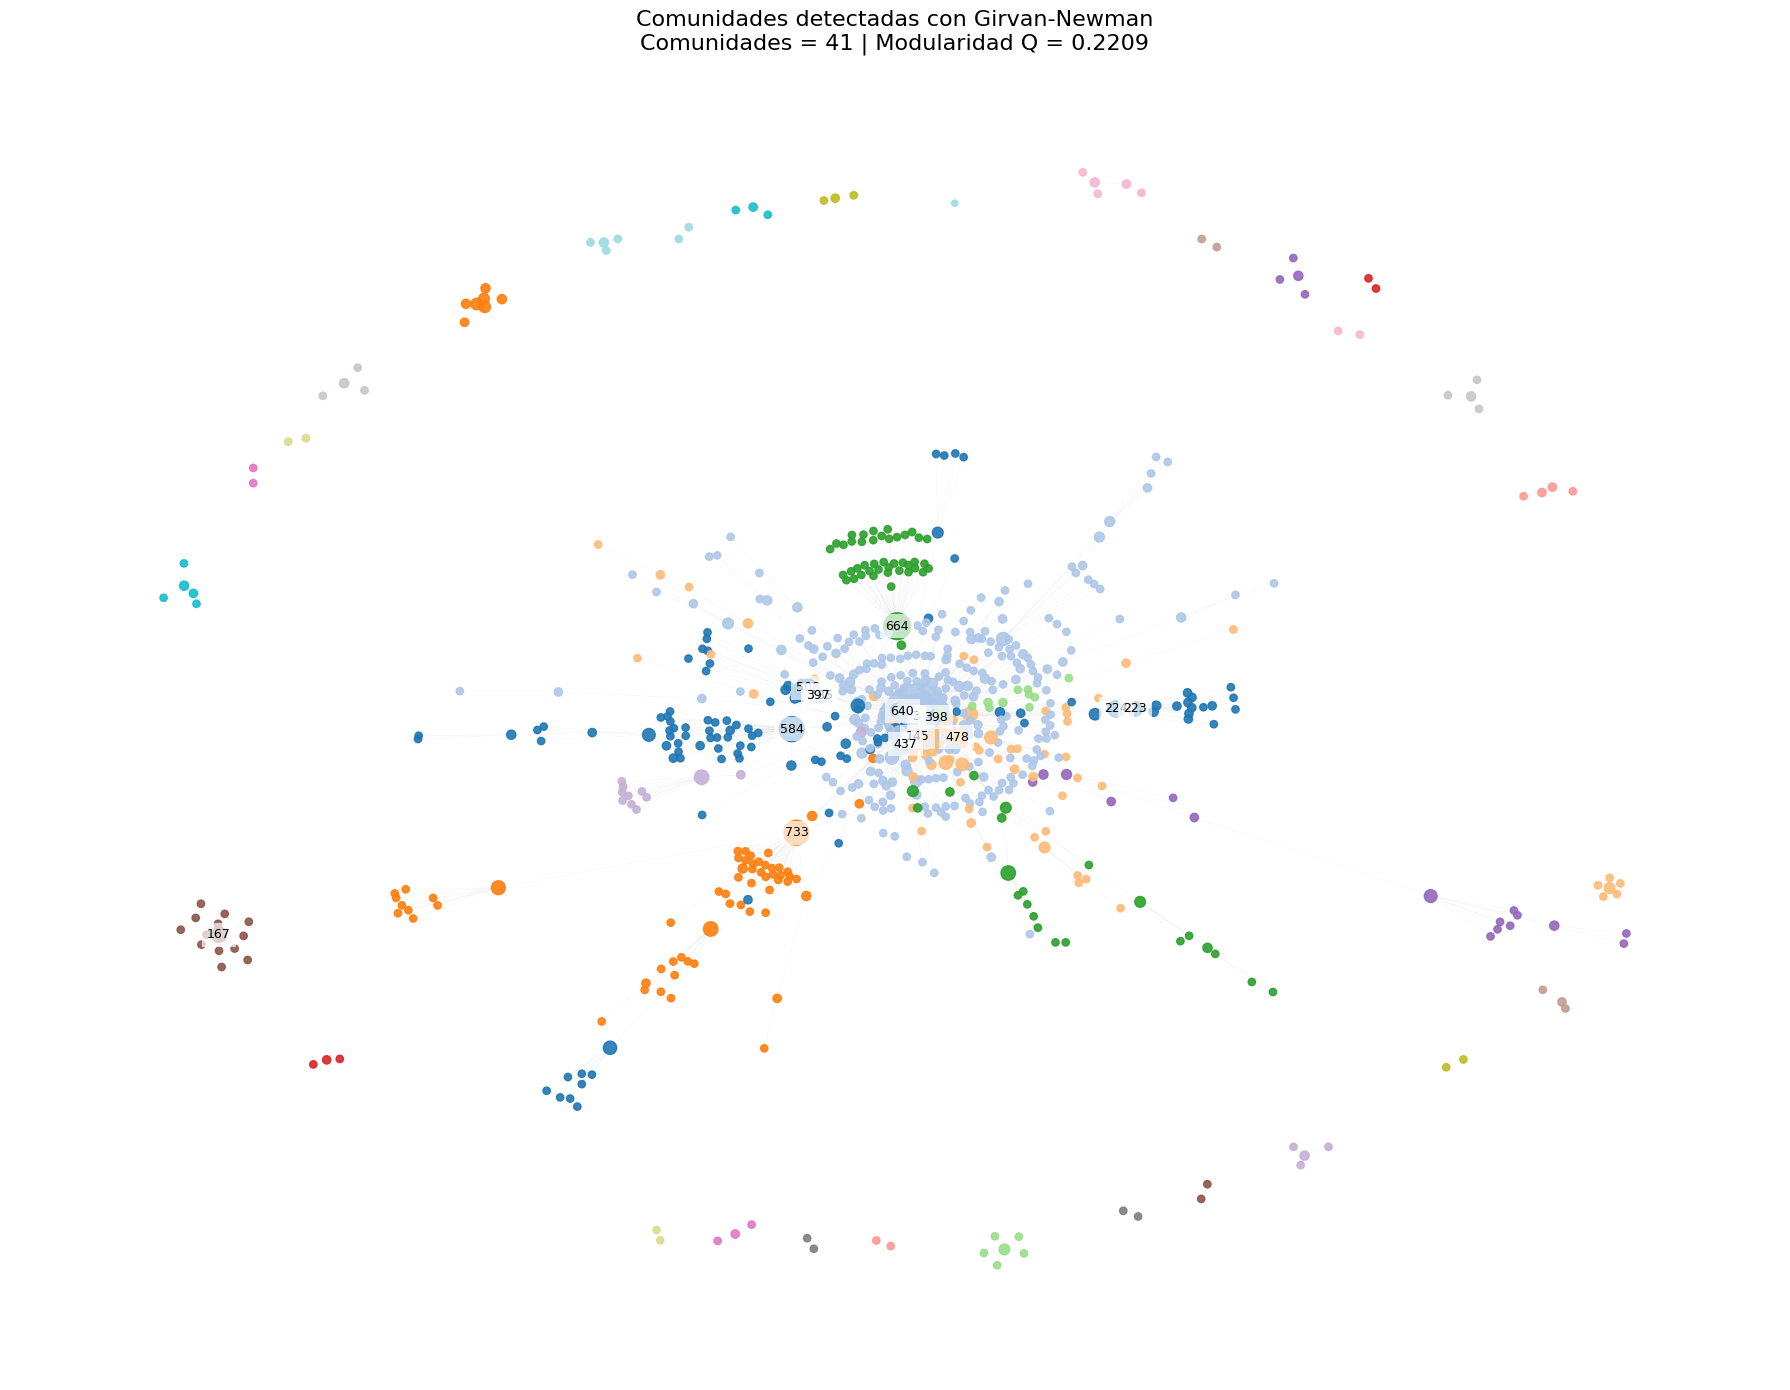

In [16]:
node_to_community = {}
for i, comunidad in enumerate(mejor_particion_gn):
    for nodo in comunidad:
        node_to_community[nodo] = i

# Colores por comunidad
num_comunidades = len(mejor_particion_gn)
cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))
node_colors = [cmap(node_to_community[n]) for n in G.nodes()]

# Tamaño de nodo según grado
degrees = dict(G.degree())
node_sizes = [20 + 8 * degrees[n] for n in G.nodes()]

# Layout más abierto
pos = nx.spring_layout(G, seed=42, k=1.2, iterations=300)

plt.figure(figsize=(18, 14))

# Aristas muy suaves
nx.draw_networkx_edges(G, pos, alpha=0.07, width=0.4, edge_color="gray")

# Nodos
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# Etiquetar solo los nodos más conectados
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:15]
labels = {n: str(n) for n in top_nodes}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color="black", bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

plt.title(f"Comunidades detectadas con Girvan-Newman\n" f"Comunidades = {len(mejor_particion_gn)} | Modularidad Q = {mejor_q:.4f}", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

### 3. Método InfoMap

**Concepto:** InfoMap detecta comunidades basándose en la teoría de la información y en cómo un "caminante aleatorio" (*random walker*) se movería por la red. La idea es agrupar los nodos de forma que se minimice la cantidad de información (llamada *codelength*) necesaria para describir la ruta de dicho caminante.

**Contexto en el grafo:** A diferencia de Louvain, que se enfoca en la densidad estructural, InfoMap refleja cómo "fluye" el contacto. Aquí, una comunidad indica un subgrupo cerrado en el que una interacción, mensaje o contacto tiene una gran probabilidad de mantenerse atrapado antes de pasar a otra comunidad.

**Explicación del código:** Iniciamos `Infomap` iterando sobre las aristas de nuestro grafo y lo ejecutamos. Luego, recuperamos y agrupamos los nodos por comunidad. Finalmente, calculamos también la modularidad para disponer de un criterio unificado de comparación.

In [13]:
# Quitar self-loops si no tienen interés analítico
G.remove_edges_from(nx.selfloop_edges(G))

print("Ejecutando InfoMap...")

# 1. Inicializar InfoMap
im = Infomap(silent=True)

# 2. Añadir el grafo y guardar el mapping NetworkX -> InfoMap
nx_to_im = im.add_networkx_graph(G)

# Invertimos el mapping para volver de InfoMap a NetworkX
im_to_nx = {v: k for k, v in nx_to_im.items()}

# 3. Ejecutar algoritmo
im.run()

print(f"InfoMap ha detectado {im.num_top_modules} comunidades.")

# 4. Reconstruir comunidades con nodos originales de NetworkX
comunidades_dict = {}
for node in im.tree:
    if node.is_leaf:
        comunidad_id = node.module_id
        nodo_original = im_to_nx[node.node_id]

        if comunidad_id not in comunidades_dict:
            comunidades_dict[comunidad_id] = set()

        comunidades_dict[comunidad_id].add(nodo_original)

comunidades_infomap = list(comunidades_dict.values())

# 5. Modularidad
q_infomap = nx.community.modularity(G, comunidades_infomap, weight="weight")
print(f"Modularidad asociada a la partición de InfoMap: {q_infomap:.4f}")

Ejecutando InfoMap...
InfoMap ha detectado 86 comunidades.
Modularidad asociada a la partición de InfoMap: 0.3280


Procedemos ahora a visualizar la red utilizando los resultados arrojados por InfoMap.

**Explicación del código:** Se asignan colores a cada nodo iterando a través del diccionario de comunidades extraído de InfoMap. Empleamos de nuevo el mismo layout de visualización y mostramos solo el "top 15" de nodos para permitir una comparación visual justa y transparente con el gráfico anterior.

/var/folders/lw/hs5rfqwn01v9260m1xbp6dlh0000gn/T/ipykernel_17793/380345542.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))


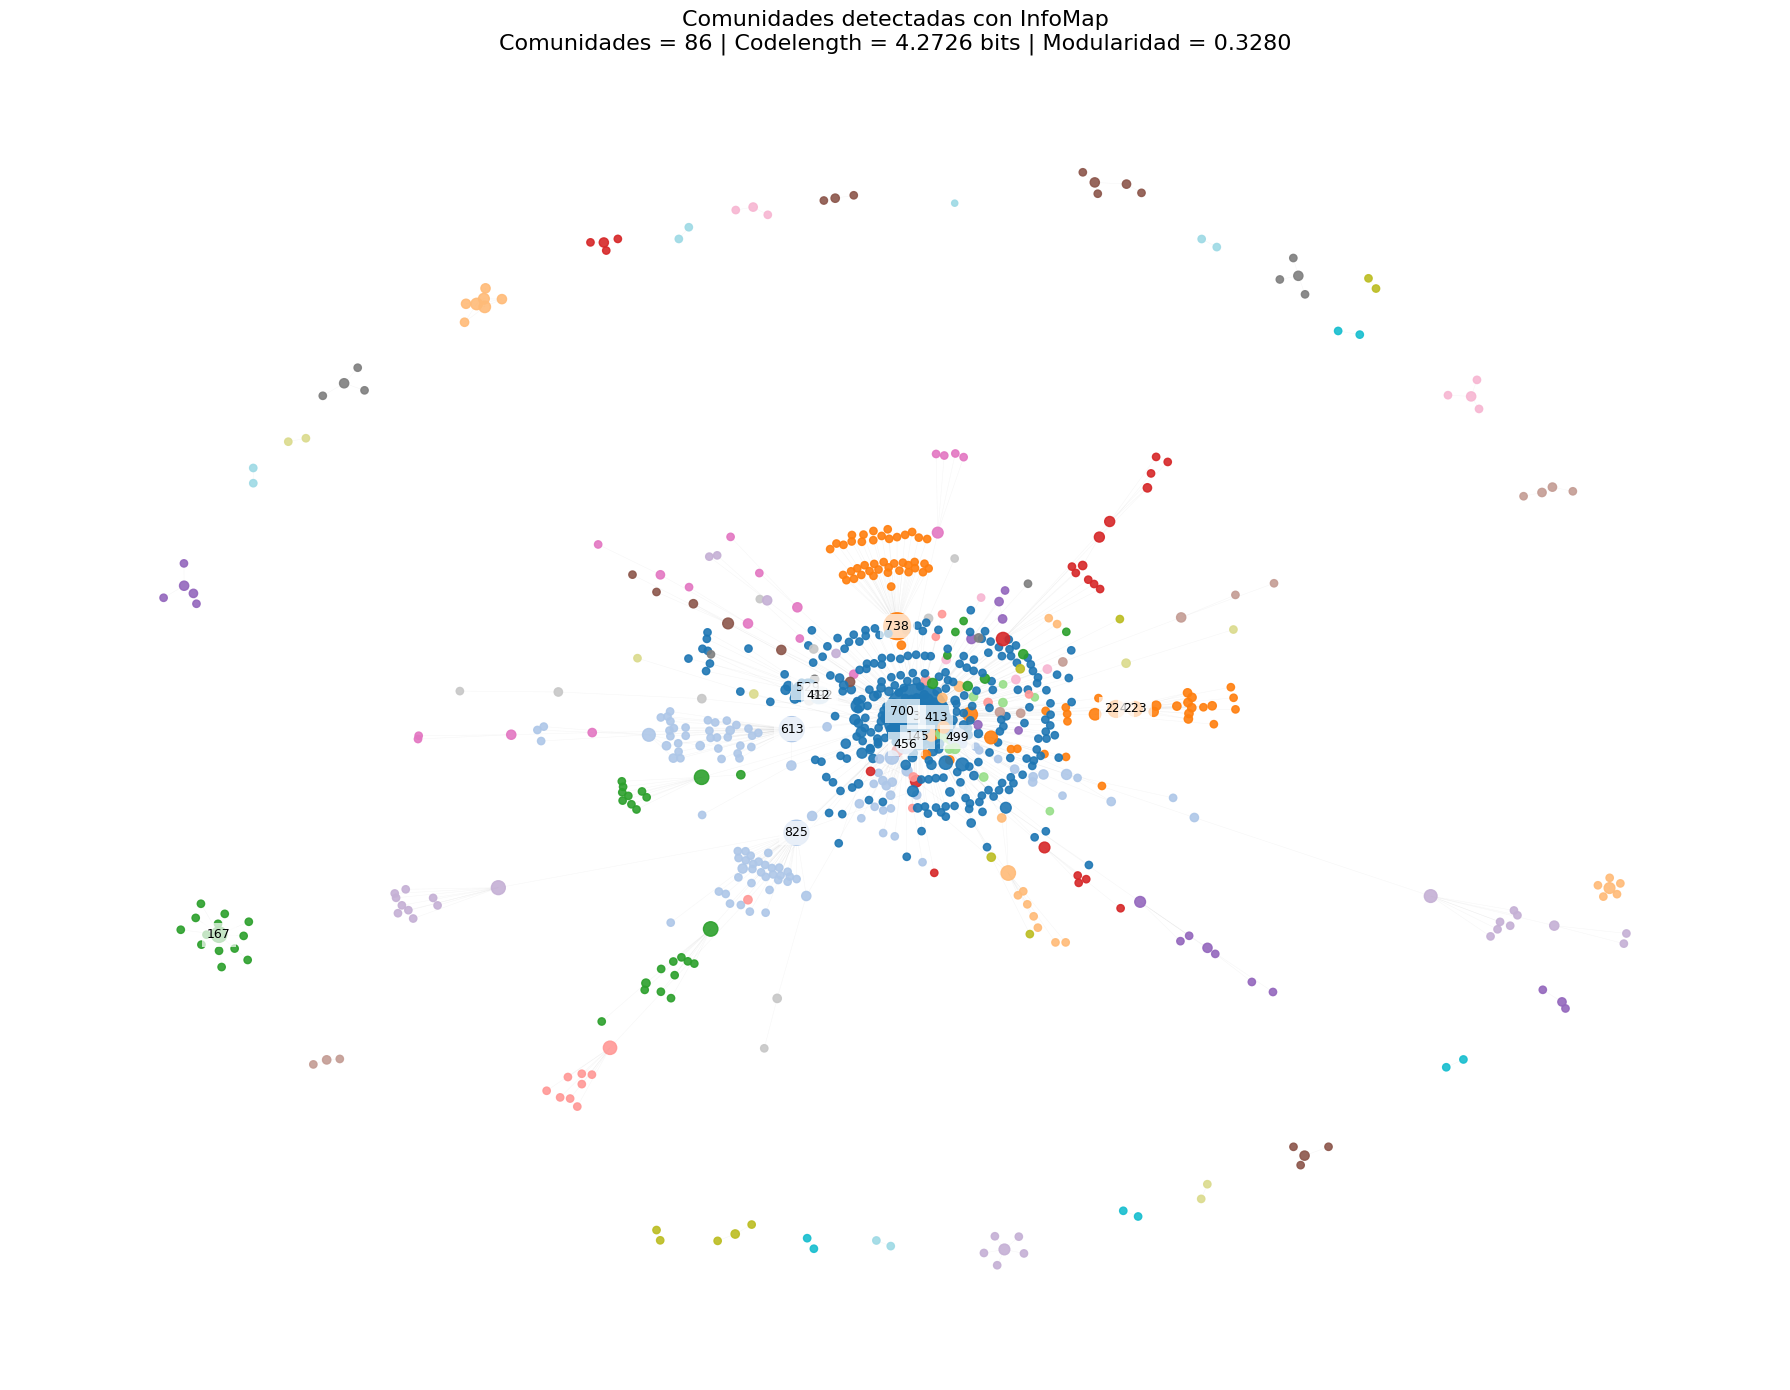

In [14]:
# Mapa nodo -> comunidad
node_to_community = {}
for i, comunidad in enumerate(comunidades_infomap):
    for nodo in comunidad:
        node_to_community[nodo] = i

# Colores por comunidad
num_comunidades = len(comunidades_infomap)
cmap = plt.cm.get_cmap("tab20", max(num_comunidades, 1))
node_colors = [cmap(node_to_community[n]) for n in G.nodes()]

# Tamaño de nodo según grado
degrees = dict(G.degree())
node_sizes = [20 + 8 * degrees[n] for n in G.nodes()]

# Layout más abierto
pos = nx.spring_layout(G, seed=42, k=1.2, iterations=300)

plt.figure(figsize=(18, 14))

nx.draw_networkx_edges(G, pos, alpha=0.07, width=0.4, edge_color="gray")

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# Etiquetar solo algunos nodos
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:15]
labels = {n: G.nodes[n].get("label", str(n)) for n in top_nodes}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color="black", bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

plt.title(f"Comunidades detectadas con InfoMap\n" f"Comunidades = {len(comunidades_infomap)} | "f"Codelength = {im.codelength:.4f} bits | "f"Modularidad = {q_infomap:.4f}", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

### Conclusión y Comparativa de Métodos

Para evaluar de forma objetiva qué algoritmo ha logrado encontrar los grupos más cohesionados, utilizamos la métrica de **Modularidad ($Q$)**. La interpretación de sus resultados es la siguiente:
* **$Q = 0$**: La partición no es mejor que una división puramente aleatoria.
* **$Q < 0$**: Los nodos de una misma comunidad están menos conectados entre sí de lo que cabría esperar por azar (un agrupamiento pobre).
* **$Q > 0.3$**: Es un indicador general de que la red posee una estructura de comunidades significativa y fuerte (valores entre 0.3 y 0.7 se consideran excelentes dentro de las redes reales).

**Resultados obtenidos:**
1. **Louvain:** 72 comunidades, **$Q = 0.3319$**
2. **InfoMap:** 55 comunidades, **$Q = 0.3168$**
3. **Girvan-Newman:** 41 comunidades, **$Q = 0.2209$**

**Interpretación Final:**
Tanto **Louvain** como **InfoMap** superan exitosamente el umbral de 0.3, confirmando que la red social de Jeffrey Epstein no es aleatoria, sino que contiene camarillas, facciones y agrupaciones sólidas y estructuradas.

De todos los métodos, **Louvain** consigue el mejor resultado (la mayor modularidad de $0.3319$), maximizando eficientemente la densidad interna a través de sus 72 grupos detectados. Por su parte, **InfoMap** resulta en una fragmentación un poco más moderada (55 comunidades), conservando igualmente una notable cohesión basada en el flujo de interacción.

Por el contrario, el algoritmo de **Girvan-Newman** presenta dificultades, tendiendo a fragmentar en exceso la red identificando hasta 41 comunidades. Esto provoca que su modularidad caiga a $0.2209$, señalando que en este tipo de grafo tan entrelazado, este método no es capaz de describir la estructura subyacente con la misma óptima precisión que Louvain o InfoMap.